<a href="https://colab.research.google.com/github/ItserX/dsp-seminars/blob/kondakov_lab4/kondakov_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


white: mean=-0.028, var= 1
pink : mean= 0, var= 1
red  : mean=-8.53e-17, var= 1


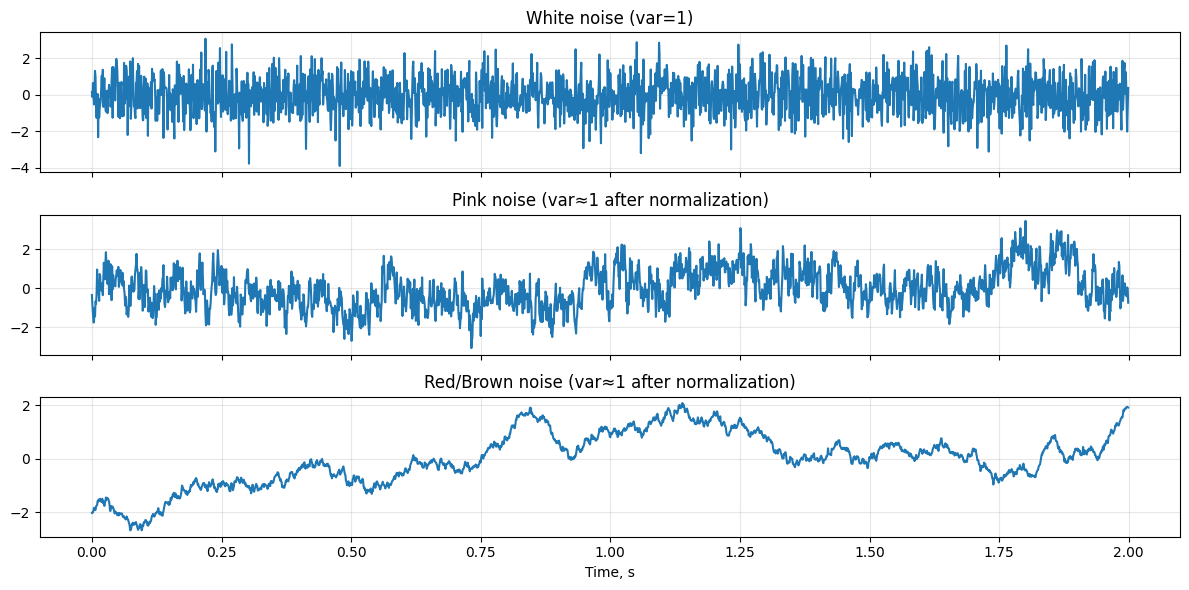

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram, welch

rng = np.random.default_rng(0)

fs = 1000
duration = 2.0
N = int(fs * duration)
t = np.arange(N) / fs


def make_white_noise(var=1.0, size=N):
    return rng.normal(0.0, np.sqrt(var), int(size))


def make_pink_noise(var=1.0, size=N, fs=fs):
    size = int(size)
    white = make_white_noise(var=1.0, size=size)

    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(size, d=1 / fs)

    scale = np.ones_like(freqs)
    scale[1:] = 1.0 / np.sqrt(freqs[1:])
    spectrum *= scale

    pink = np.fft.irfft(spectrum, n=size)
    pink = (pink - np.mean(pink)) / np.std(pink)
    return pink * np.sqrt(var)


def make_red_noise(var=1.0, size=N):
    size = int(size)
    white = make_white_noise(var=1.0, size=size)
    red = np.cumsum(white)
    red = (red - np.mean(red)) / np.std(red)
    return red * np.sqrt(var)


white = make_white_noise(var=1.0)
pink = make_pink_noise(var=1.0)
red = make_red_noise(var=1.0)

for name, x in [('white', white), ('pink', pink), ('red', red)]:
    print(f'{name:5s}: mean={x.mean(): .3g}, var={x.var(): .3g}')

fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axs[0].plot(t, white)
axs[0].set_title('White noise (var=1)')
axs[1].plot(t, pink)
axs[1].set_title('Pink noise (var≈1 after normalization)')
axs[2].plot(t, red)
axs[2].set_title('Red/Brown noise (var≈1 after normalization)')
axs[2].set_xlabel('Time, s')
for ax in axs:
    ax.grid(True, alpha=0.3)
plt.tight_layout()


**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Визуально белый шум выглядит часто сменяющимся; розовый шум содержит больше низких частот и поэтому выглядит более плавным; красный самый гладкий.

Средние и дисперсии должны быть близки к 0 и 1, но не обязаны совпадать идеально из-за конечной длины реализации и случайности. Для розового/красного шума добавляется небольшая погрешность из-за способа генерации и последующей нормировки.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


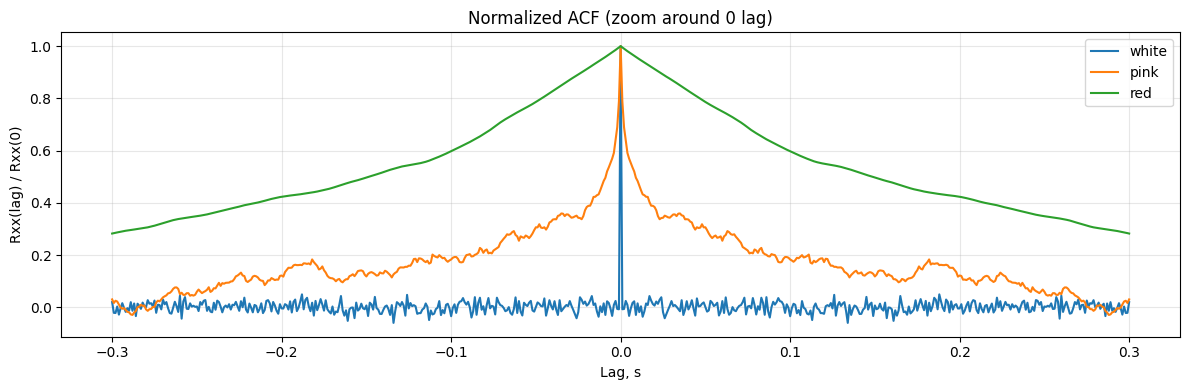

In [2]:
def norm_acf(x):
    r = np.correlate(x, x, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    r = r / r[len(x) - 1]
    return lags, r


lags, acf_white = norm_acf(white)
_, acf_pink = norm_acf(pink)
_, acf_red = norm_acf(red)

max_lag = 300  # samples
mask = (lags >= -max_lag) & (lags <= max_lag)

plt.figure(figsize=(12, 4))
plt.plot(lags[mask] / fs, acf_white[mask], label='white')
plt.plot(lags[mask] / fs, acf_pink[mask], label='pink')
plt.plot(lags[mask] / fs, acf_red[mask], label='red')
plt.title('Normalized ACF (zoom around 0 lag)')
plt.xlabel('Lag, s')
plt.ylabel('Rxx(lag) / Rxx(0)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Чем ближе к дельта-функции автокорреляционная функция, тем менее гладкий сигнал. У белого шума значения почти некоррелированы, поэтому АКФ быстро падает к нулю и временная реализация выглядит очень "шероховатой". У розового и особенно у красного шума есть длительные корреляции (АКФ убывает медленнее), поэтому соседние отсчёты более похожи друг на друга, и реализация выглядит более плавной.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


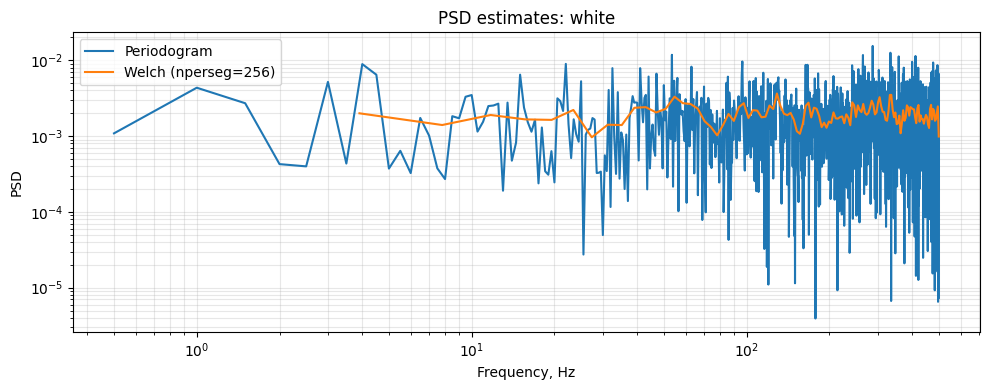

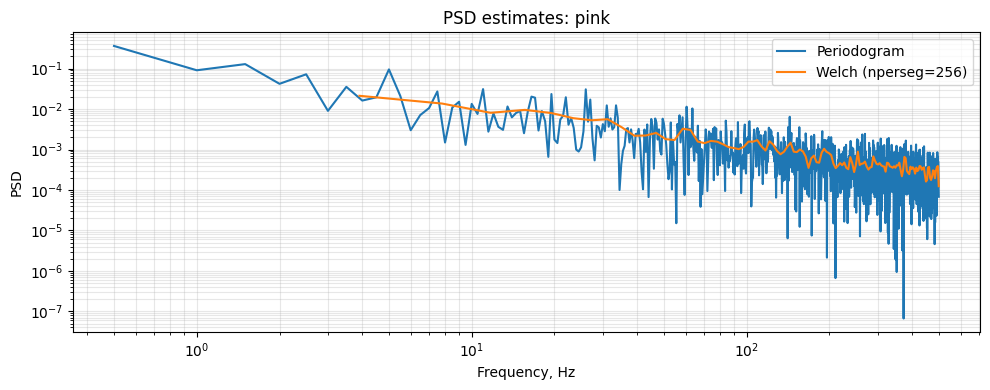

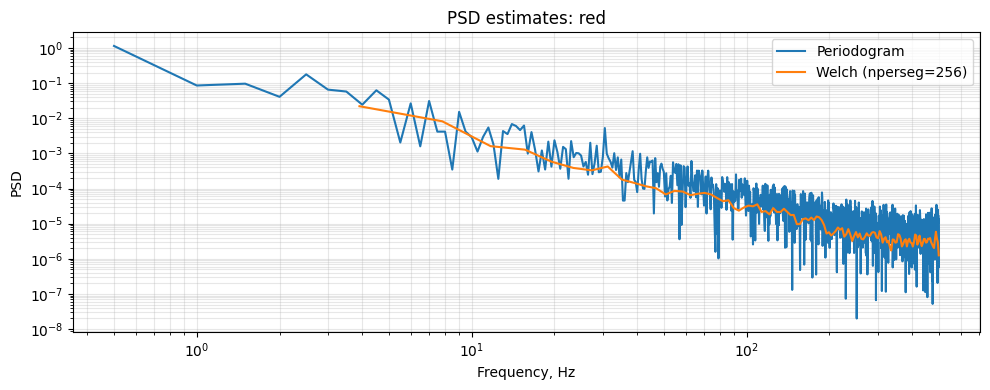

In [3]:
noises = {'white': white, 'pink': pink, 'red': red}

for name, x in noises.items():
    f_per, P_per = periodogram(x, fs=fs, scaling='density')
    f_w, P_w = welch(
        x,
        fs=fs,
        nperseg=256,
        noverlap=128,
        window='hann',
        scaling='density',
    )

    plt.figure(figsize=(10, 4))
    plt.loglog(f_per[1:], P_per[1:], label='Periodogram')
    plt.loglog(f_w[1:], P_w[1:], label='Welch (nperseg=256)')
    plt.title(f'PSD estimates: {name}')
    plt.xlabel('Frequency, Hz')
    plt.ylabel('PSD')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()


**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


В двойном логарифмическом масштабе:
- белый шум даёт почти горизонтальную линию (СПМ ≈ const),
- розовый шум убывает примерно как 1/f (наклон около −1),
- красный шум убывает примерно как 1/f^2 (наклон около −2).

Периодограмма выглядит более "зубчатой", оценка Уэлча — более гладкой за счёт усреднения.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


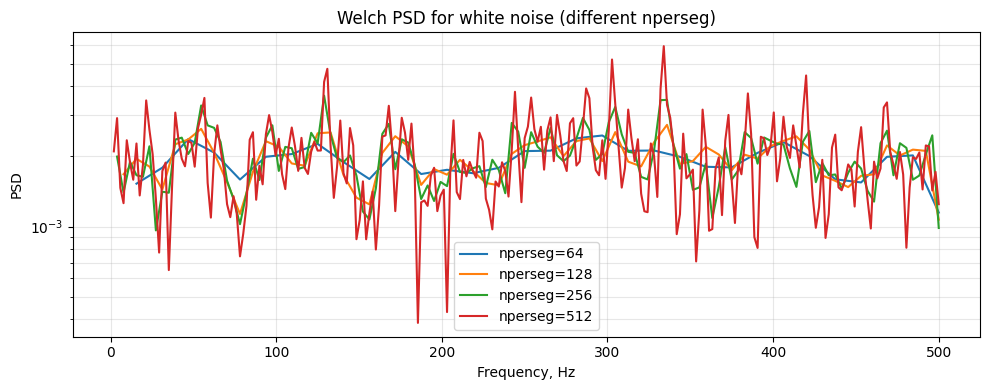

In [4]:
plt.figure(figsize=(10, 4))
for nperseg in [64, 128, 256, 512]:
    f, P = welch(
        white,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
        scaling='density',
    )
    plt.semilogy(f[1:], P[1:], label=f'nperseg={nperseg}')

plt.title('Welch PSD for white noise (different nperseg)')
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()


**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При увеличении длины сегмента `nperseg` улучшается частотное разрешение.

Одновременно оценка обычно становится менее гладкой, потому что при фиксированной длине сигнала получается меньше сегментов для усреднения в методе Уэлча.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

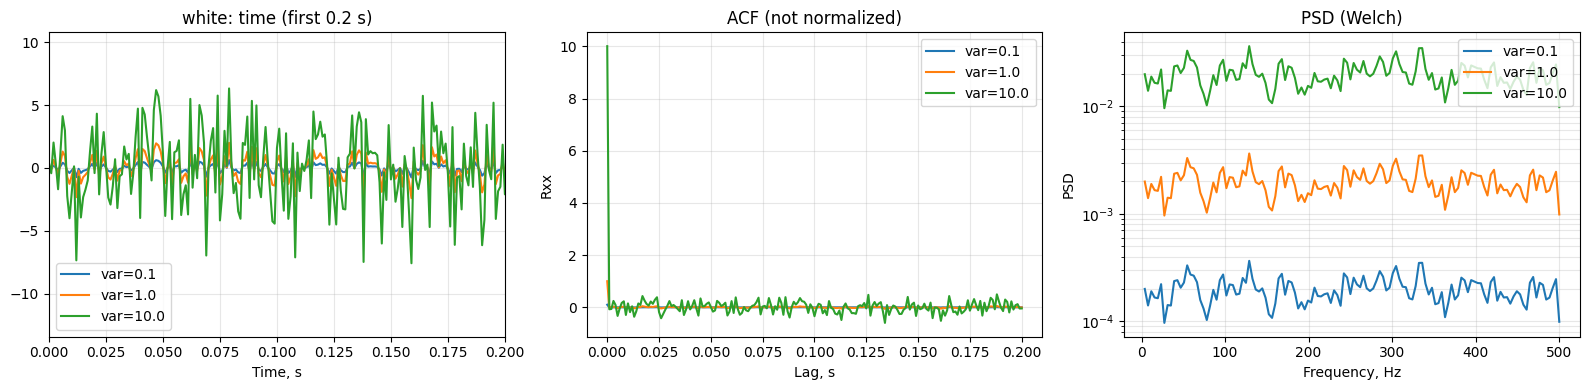

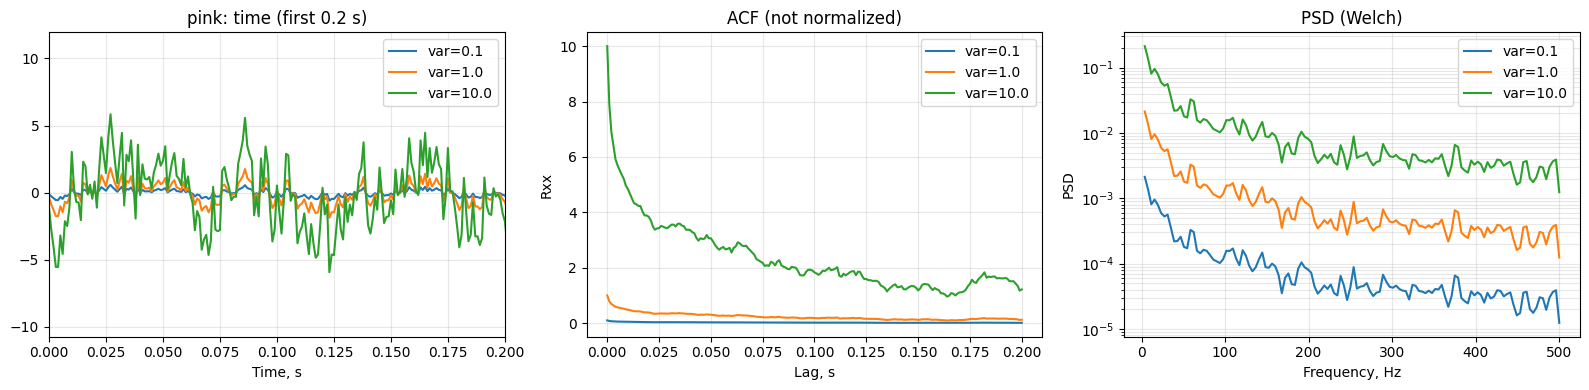

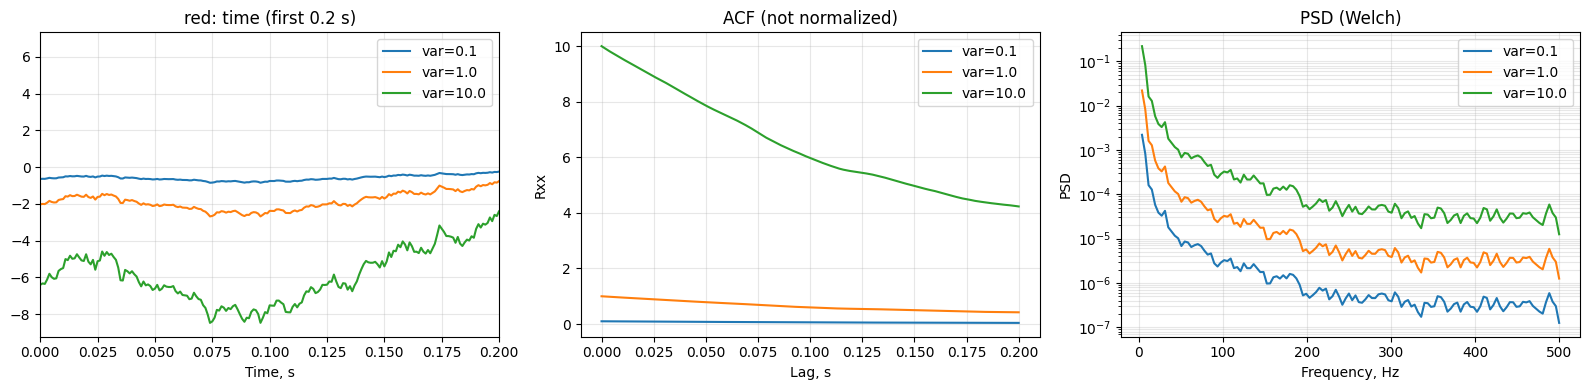

In [5]:
variances = [0.1, 1.0, 10.0]
bases = {'white': white, 'pink': pink, 'red': red}

for name, base in bases.items():
    fig, axs = plt.subplots(1, 3, figsize=(16, 4))

    for var in variances:
        x = base * np.sqrt(var)

        axs[0].plot(t, x, label=f'var={var}')

        r = np.correlate(x, x, mode='full') / len(x)
        r_pos = r[len(x) - 1 :]
        lags_pos = np.arange(len(x)) / fs
        m = lags_pos <= 0.2
        axs[1].plot(lags_pos[m], r_pos[m], label=f'var={var}')

        f, P = welch(
            x,
            fs=fs,
            nperseg=256,
            noverlap=128,
            window='hann',
            scaling='density',
        )
        axs[2].semilogy(f[1:], P[1:], label=f'var={var}')

    axs[0].set_title(f'{name}: time (first 0.2 s)')
    axs[0].set_xlim(0, 0.2)
    axs[0].set_xlabel('Time, s')

    axs[1].set_title('ACF (not normalized)')
    axs[1].set_xlabel('Lag, s')
    axs[1].set_ylabel('Rxx')

    axs[2].set_title('PSD (Welch)')
    axs[2].set_xlabel('Frequency, Hz')
    axs[2].set_ylabel('PSD')

    for ax in axs:
        ax.grid(True, which='both', alpha=0.3)
        ax.legend()

    plt.tight_layout()


**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


Меняется уровень сигнала:
- во временной области амплитуды растут как sqrt(дисперсии),
- АКФ без нормировки масштабируется по оси Y (значение при нулевом лаге ≈ дисперсия),
- СПМ также масштабируется по уровню пропорционально дисперсии.

При этом форма АКФ и форма спектра остаются примерно такими же, меняется в основном высота, а не "форма".

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


SNR= 10 dB: noise_var=0.05, peak≈110.35 Hz
SNR=  0 dB: noise_var=0.5, peak≈110.35 Hz
SNR=-10 dB: noise_var=5, peak≈110.35 Hz
SNR=-20 dB: noise_var=50, peak≈110.35 Hz


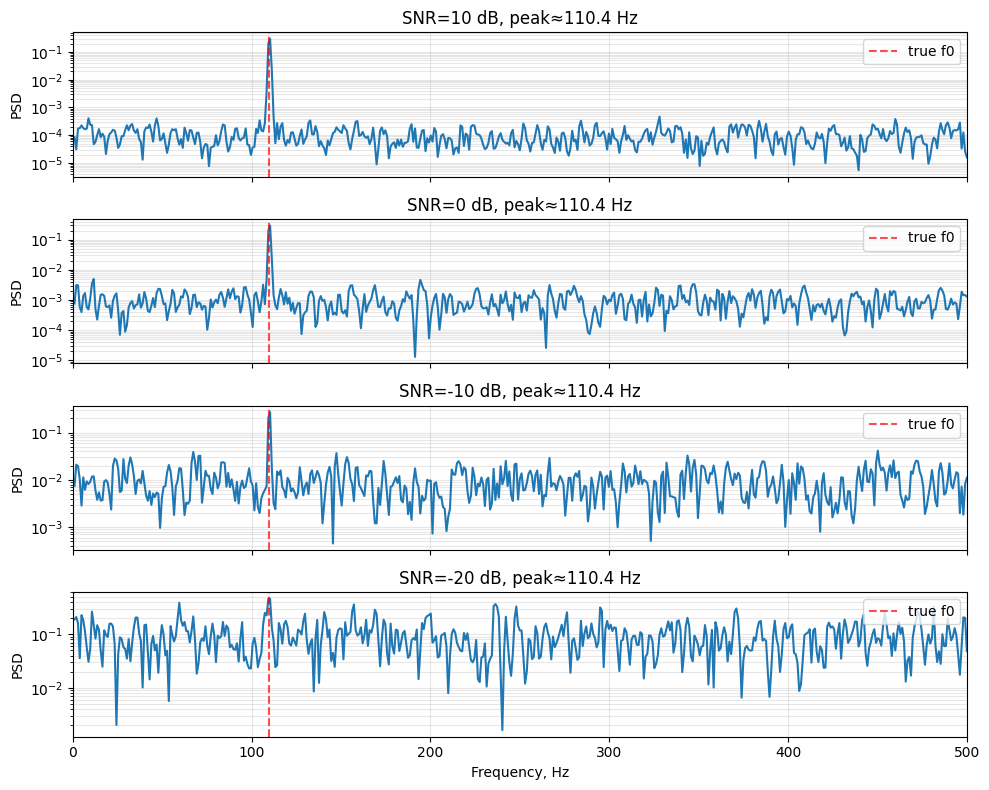

In [6]:
A = 1.0
f0 = 110.0
pure = A * np.sin(2 * np.pi * f0 * t)
P_sig = A**2 / 2

snrs_db = [10, 0, -10, -20]
nperseg = 1024

fig, axs = plt.subplots(len(snrs_db), 1, figsize=(10, 8), sharex=True)

for ax, snr_db in zip(axs, snrs_db):
    snr_lin = 10 ** (snr_db / 10)
    P_noise = P_sig / snr_lin
    noise = rng.normal(0.0, np.sqrt(P_noise), N)
    x = pure + noise

    f, P = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
        scaling='density',
    )

    mask = (f > 1) & (f < fs / 2)
    f_peak = f[mask][np.argmax(P[mask])]

    ax.semilogy(f[1:], P[1:])
    ax.axvline(f0, color='r', linestyle='--', alpha=0.7, label='true f0')
    ax.set_title(f'SNR={snr_db} dB, peak≈{f_peak:.1f} Hz')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='upper right')

    print(f'SNR={snr_db:>3} dB: noise_var={P_noise:.4g}, peak≈{f_peak:.2f} Hz')

axs[-1].set_xlabel('Frequency, Hz')
axs[-1].set_xlim(0, 500)
for ax in axs:
    ax.set_ylabel('PSD')
plt.tight_layout()


**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


С уменьшением SNR шумовой фон относительно пика растёт - на спектре пик на 110 Гц становится ниже относительно окружающих значений и в какой-то момент перестаёт выделяться.

Визуально обычно уверенно видно пик при SNR около 0-10 дБ. При SNR порядка −10 дБ пик может быть заметен только при удачных параметрах оценки, а при −20 дБ и ниже часто тонет в шуме.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


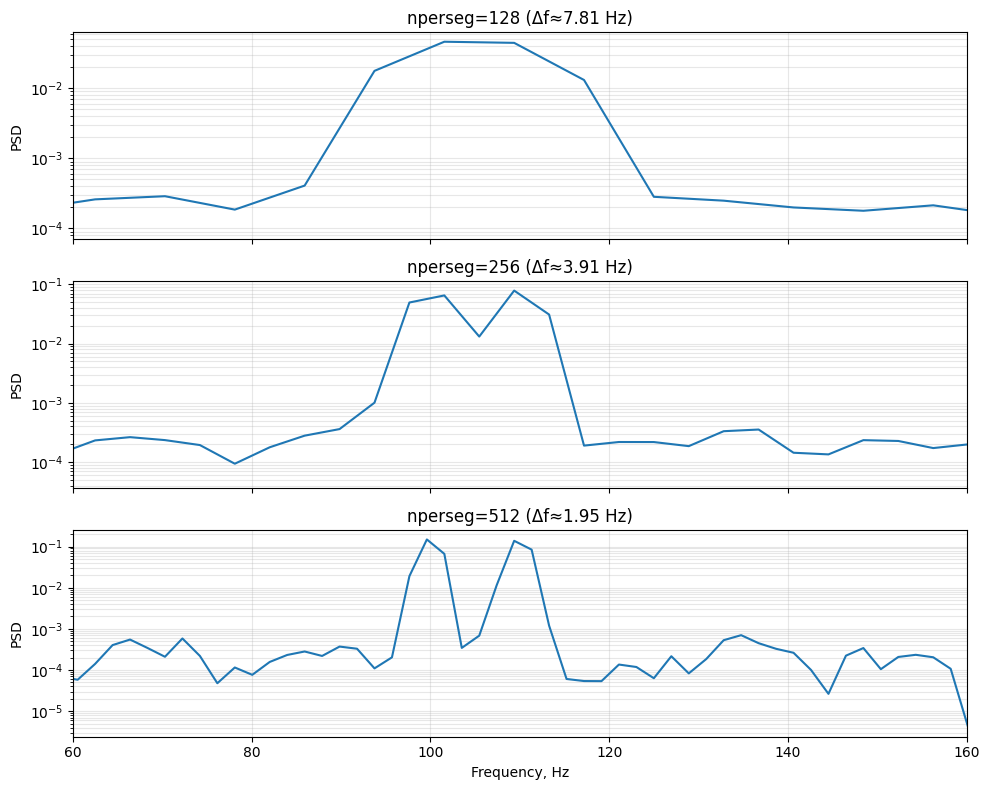

In [7]:
duration2 = 1.0
N2 = int(fs * duration2)
t2 = np.arange(N2) / fs

x = (
    np.sin(2 * np.pi * 100 * t2)
    + np.sin(2 * np.pi * 110 * t2)
    + rng.normal(0.0, np.sqrt(0.1), N2)
)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, nperseg in zip(axs, [128, 256, 512]):
    f, P = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
        scaling='density',
    )
    ax.semilogy(f[1:], P[1:])
    ax.set_title(f'nperseg={nperseg} (Δf≈{fs / nperseg:.2f} Hz)')
    ax.set_xlim(60, 160)
    ax.grid(True, which='both', alpha=0.3)

axs[-1].set_xlabel('Frequency, Hz')
for ax in axs:
    ax.set_ylabel('PSD')
plt.tight_layout()


**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


На практике чаще всего хорошо разделить 100 и 110 Гц удаётся при `nperseg` = 256 или 512 (лучше при 512), потому что оценка имеет достаточное частотное разрешение.

Грубая оценка Δf ≈ fs / Nseg даёт: для 128: ~7.8 Гц, для 256: ~3.9 Гц, для 512: ~1.95 Гц